#Usin EMCEE

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
import scipy.integrate as integrate

from getdist import plots, MCSamples
import getdist
import IPython


import numpy as np
import emcee
import matplotlib.pyplot as plt

In [9]:
import numpy as np
from scipy import integrate

# -------- constants & helpers --------
c = 299_792.458  # km/s

def Omega_gamma(h):
    return 2.47e-5 / (h*h)

def Omega_nu(h):
    # 3*(7/8)*(4/11)^(4/3) * Omega_gamma(h)
    return 3.0 * 7.0/8.0 * (4.0/11.0)**(4.0/3.0) * Omega_gamma(h)

def S(alpha, beta, z):
    # -1 + exp(-beta*(z-alpha)^2)
    # make it vectorized-safe
    z = np.asarray(z)
    return alpha * np.exp(-(z-beta[0])**2 * beta[1])
#alpha*(1-np.tanh((z-beta[0]) * beta[1])**2)
# #np.exp(-((z - 1.5)**2) * beta)

def b1(h, Omega_c, Omega_b):
    Om = Omega_b + Omega_c
    x = (Om * h*h)
    return 0.313 / (x**0.419) * (1.0 + 0.607 * (x**0.674))

def b2(h, Omega_c, Omega_b):
    Om = Omega_b + Omega_c
    x = (Om * h*h)
    return 0.238 * (x**0.223)

def zd(h, Omega_c, Omega_b):
    Om = Omega_b + Omega_c
    x = (Om * h*h)
    v1 = 1345.0 * (x**0.251) * (1.0 + b1(h, Omega_c, Omega_b) * (Omega_b*h*h)**b2(h, Omega_c, Omega_b))
    return v1 / (1.0 + 0.659 * (x**0.828))

def g1(h, Omega_c, Omega_b):
    x = (Omega_b * h*h)
    return 0.0783 / (x**0.238) / (1.0 + 39.5 * (x**0.763))

def g2(h, Omega_c, Omega_b):
    x = (Omega_b * h*h)
    return 0.56 / (1.0 + 21.1 * (x**1.81))

def zs(h, Omega_c, Omega_b):
    Om = Omega_b + Omega_c
    x = (Omega_b * h*h)
    return 1048.0*(1.0 + 0.00124 / (x**0.738)) * (1.0 + g1(h, Omega_c, Omega_b)*(Om*h*h)**g2(h, Omega_c, Omega_b))

# Vectorized c_s(z) and H(z)
def _cs(H0_h, Og, Ob, z):
    # H0_h is just h; we only need Og (Omega_gamma) here
    # c_s = c * sqrt( 1 / [3 * (1 + 3*Ωb / (4 Ωγ (1+z)))] )
    z = np.asarray(z)
    return c * np.sqrt(1.0 / (3.0 * (1.0 + 3.0*Ob / (4.0*Og*(1.0+z)))))

def _E_of_z(h, Om, Or, alpha, beta, S0, z):
    # E(z) = H(z) / (100 h)
    # sqrt( Om(1+z)^3 + Or(1+z)^4 + (1-Om-Or) ) * (1+S0)/(1+S(alpha,beta,z))
    z = np.asarray(z)
    term = Om*(1.0+z)**3 + Or*(1.0+z)**4 + (1.0 - Om - Or)
    return np.sqrt(term) * ((1.0 + S0) / (1.0 + S(alpha, beta, z)))

def _H_of_z(h, Om, Or, alpha, beta, S0, z):
    return 100.0*h * _E_of_z(h, Om, Or, alpha, beta, S0, z)

# ---- fast integrals via reusable grids ----
def _comoving_distance_grid(h, Om, Or, alpha, beta, S0, z_max, N=6000):
    """
    Returns z_grid (ascending) and MD_grid where
    MD(z) = int_0^z c / H(z') dz'
    Uses uniform spacing (good for low z up to ~1e3 scale).
    """
    z_grid = np.linspace(0.0, z_max, N)
    Hz = _H_of_z(h, Om, Or, alpha, beta, S0, z_grid)
    integ = c / Hz  # vectorized
    # cumulative trapezoid (manual to avoid SciPy call overhead)
    # MD[k] = sum_{i<k} 0.5*(f[i]+f[i+1])*(z[i+1]-z[i])
    dz = z_grid[1] - z_grid[0]
    # trapezoid via prefix sum
    # mid-sum on uniform grid: integral ~ dz*(0.5*f0 + f1 + ... + 0.5*fN)
    # build cumulative efficiently:
    mid = integ.copy()
    mid[0] *= 0.5
    mid[-1] *= 0.5
    cumsum = np.cumsum(mid)
    MD = dz * cumsum
    return z_grid, MD

def _integral_cs_over_H_from(h, Om, Or, Ob, Og, alpha, beta, S0, z_lo, z_hi=1e5, N=4000):
    """
    Compute int_{z_lo}^{z_hi} c_s(z)/H(z) dz on a log-spaced grid.
    The tail above ~1e5 contributes negligibly; N ~ 2–5k is usually enough.
    """
    # logspace grid (avoid z=0)
    z_lo = float(z_lo)
    if z_hi <= z_lo:
        return 0.0
    z_grid = np.geomspace(z_lo + 1e-9, z_hi, N)
    Hz = _H_of_z(h, Om, Or, alpha, beta, S0, z_grid)
    cs = _cs(h, Og, Ob, z_grid)
    y = cs / Hz
    # trapezoid on non-uniform grid
    return np.trapz(y, z_grid)

# --------- fast versions of your derived quantities ---------
def theta100_fast(h, Omega_c, Omega_b, alpha, beta,
                  pre=None):
    """
    Uses precomputed grids for MD and vectorized integral for rs.
    """
    # Unpack / prepare cached common terms
    if pre is None:
        pre = {}
    Om = Omega_b + Omega_c
    Og = pre.get('Og') or Omega_gamma(h)
    Onu = pre.get('Onu') or Omega_nu(h)
    Or = Og + Onu
    S0 = pre.get('S0') or S(alpha, beta, 0.0)
    zs_val = pre.get('zs') or zs(h, Omega_c, Omega_b)

    # Precompute MD grid up to max(zs_val, z list below)
    z_max = zs_val  # need MD(zs)
    z_grid, MD = pre.get('MD_grid', (None, None))
    if z_grid is None or z_grid[-1] < z_max or pre.get('alpha_beta_h_Om', None) != (alpha, beta, h, Om):
        z_grid, MD = _comoving_distance_grid(h, Om, Or, alpha, beta, S0, z_max=z_max, N=5000)
        pre['MD_grid'] = (z_grid, MD)
        pre['alpha_beta_h_Om'] = (alpha, beta, h, Om)

    # Interpolate MD(zs)
    md_zs = np.interp(zs_val, z_grid, MD)

    # Compute rs = ∫_{zs}^{z_hi} cs/H dz on a log-spaced grid
    rs_val = _integral_cs_over_H_from(h, Om, Or, Omega_b, Og, alpha, beta, S0, z_lo=zs_val, z_hi=1e5, N=3000)
    return 100.0 * rs_val / md_zs, pre

def vd_fast(h, Omega_c, Omega_b, z, alpha, beta, pre=None):
    """
    vd = (md(z)^2 * c * z / H(z))^(1/3)
    md(z) via precomputed MD grid; H(z) vectorized; no quads.
    """
    if pre is None:
        pre = {}
    Om = Omega_b + Omega_c
    Og = pre.get('Og') or Omega_gamma(h)
    Onu = pre.get('Onu') or Omega_nu(h)
    Or = Og + Onu
    S0 = pre.get('S0') or S(alpha, beta, 0.0)

    z = float(z)
    # Ensure MD grid covers this z
    z_grid, MD = pre.get('MD_grid', (None, None))
    if z_grid is None or z_grid[-1] < z or pre.get('alpha_beta_h_Om', None) != (alpha, beta, h, Om):
        z_max = max(z, pre.get('zs', 0.0))
        z_grid, MD = _comoving_distance_grid(h, Om, Or, alpha, beta, S0, z_max=z_max, N=4000)
        pre['MD_grid'] = (z_grid, MD)
        pre['alpha_beta_h_Om'] = (alpha, beta, h, Om)

    md_z = float(np.interp(z, z_grid, MD))
    Hz = float(_H_of_z(h, Om, Or, alpha, beta, S0, z))
    return (md_z*md_z * c * z / Hz)**(1.0/3.0), pre

def rd_fast(h, Omega_c, Omega_b, alpha, beta, pre=None):
    # rd = ∫_{zd}^{∞} cs/H dz
    if pre is None:
        pre = {}
    Om = Omega_b + Omega_c
    Og = pre.get('Og') or Omega_gamma(h)
    Onu = pre.get('Onu') or Omega_nu(h)
    Or = Og + Onu
    S0 = pre.get('S0') or S(alpha, beta, 0.0)
    zd_val = pre.get('zd') or zd(h, Omega_c, Omega_b)
    return _integral_cs_over_H_from(h, Om, Or, Omega_b, Og, alpha, beta, S0, z_lo=zd_val, z_hi=1e5, N=3000)

# --------- chi2 with caching & vectorization ----------
def chi2_fast(h, Omega_c, Omega_b, alpha, beta):
    """
    Faster version of your chi2. Reuses grids and vectorized integrals.
    """
    pre = {}
    Om = Omega_b + Omega_c
    pre['Og'] = Omega_gamma(h)
    pre['Onu'] = Omega_nu(h)
    pre['S0'] = S(alpha, beta, 0.0)
    pre['zs'] = zs(h, Omega_c, Omega_b)
    pre['zd'] = zd(h, Omega_c, Omega_b)

    # rd
    rd_val = rd_fast(h, Omega_c, Omega_b, alpha, beta, pre=pre)

    # 100*theta
    theta100_val, pre = theta100_fast(h, Omega_c, Omega_b, alpha, beta, pre=pre)

    # DESI z points (grouped to reuse MD/H)
    zs_list = np.array([0.295, 0.510, 0.706, 0.934, 1.321, 1.484, 2.330, 0.922, 0.955])

    vd_vals = []
    for z in zs_list:
        vdz, pre = vd_fast(h, Omega_c, Omega_b, z, alpha, beta, pre=pre)
        vd_vals.append(vdz)
    vd_vals = np.array(vd_vals)

    # Build chi^2
    chi_squared = 0.0
    chi_squared += ((theta100_val - 1.04077)/0.00047)**2  # 100*theta

    # map vd/rd to provided means/sigmas in original order
    mus = np.array([7.942, 12.720, 16.050, 19.721, 24.252, 26.055, 31.267, 19.656, 20.008])
    sig = np.array([0.075, 0.099, 0.110, 0.091, 0.174, 0.398, 0.256, 0.105, 0.183])

    chi_squared += np.sum(((vd_vals/rd_val - mus)/sig)**2)

    return float(chi_squared)


In [16]:

# ------------------ 1. Define your cost (negative log-likelihood) ------------------
def cost_function(theta):
    """Example: Rosenbrock function"""

    h, omega_c, alpha, beta0, beta1 = theta

    omega_b = 0.02212/h**2

    res = chi2_fast(h,omega_c, omega_b, alpha, [beta0,beta1])
    return res


# ------------------ 2. Define log-probability ------------------
# Convert cost into a log-probability. Lower cost = higher probability.
def log_probability(theta, bounds):
    # Uniform prior within bounds
    for val, (lo, hi) in zip(theta, bounds):
        if not (lo <= val <= hi):
            return -np.inf  # outside bounds
    return -cost_function(theta)  # logp ∝ -cost


# ------------------ 3. Setup parameters ------------------
bounds = [(0.5,3), (0,0.3 ), (0,1.5),(0,2),(0,5)]
ndim = len(bounds)
nwalkers = 20

initial = np.array([(low + high) / 2 for low, high in bounds])
p0 = initial + 5e-2 * np.random.randn(nwalkers, ndim)  # randomize walkers


# ------------------ 4. Run MCMC ------------------
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=[bounds])
print("Running MCMC...")
sampler.run_mcmc(p0, 50000, progress=True)

# Get flattened chain (discard burn-in)
samples = sampler.get_chain(discard=100, thin=10, flat=True)
print("Final shape of samples:", samples.shape)


# ------------------ 5. Analyze results ------------------
best_idx = np.argmin([cost_function(s) for s in samples])
best_params = samples[best_idx]
print("Best parameters:", best_params)
print("Best cost:", cost_function(best_params))



Running MCMC...


100%|██████████| 50000/50000 [30:03<00:00, 27.72it/s]


Final shape of samples: (99800, 5)
Best parameters: [1.06614651 0.09439245 0.25270745 0.61288344 0.64859448]
Best cost: 12.321391279073692


Removed no burn in


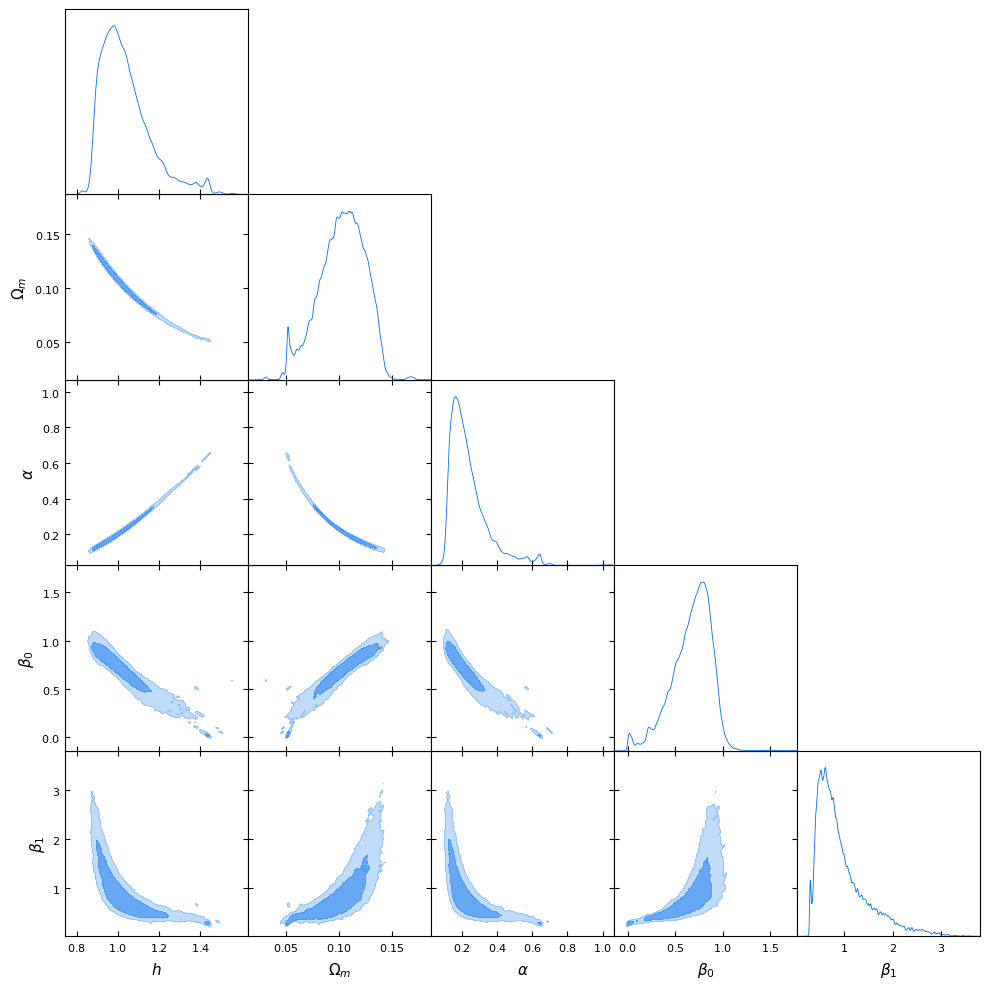

Best parameters: [1.06614651 0.09439245 0.25270745 0.61288344 0.64859448]
Best cost: 12.321391279073692


In [17]:
# Install once per runtime (Colab):
# !pip install -q getdist

import numpy as np
import matplotlib.pyplot as plt
from getdist import plots, MCSamples

# You already have: samples (N,D) and cost_function(theta) -> chi^2
names  = ['h', 'omega', 'alpha', 'beta0','beta1']
labels = [r'h', r'\Omega_m', r'\alpha', r'\beta_0',r'\beta_1']  # adjust labels to taste

# Use chi^2 as weights (optional but recommended)
chi2s = np.array([cost_function(s) for s in samples])
mask = np.isfinite(chi2s)
samples_f = samples[mask]
loglikes  = -0.5 * chi2s[mask]

# Optional axis ranges keep plots tidy
# ranges = {'h':[0.4,1.0], 'omega':[0.05,0.5], 'alpha':[0.0,5.0], 'beta':[0.0,50.0]}
mc = MCSamples(samples=samples_f, names=names, labels=labels, loglikes=loglikes)  # sampler arg omitted

# Plotter + a couple of safe settings
g = plots.get_subplot_plotter()
g.settings.num_plot_contours = 2        # 68% and 95%

# Triangle with filled contours; pass alpha via contour_args
g.triangle_plot(mc, params=names, filled=True, contour_args={'alpha': 0.6})
plt.show()

# Best point (be sure to compute on the finite subset)
best_idx = np.argmin(chi2s[mask])
best_params = samples_f[best_idx]
print("Best parameters:", best_params)
print("Best cost:", float(chi2s[mask][best_idx]))
